In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from transformers import BertTokenizer, BertModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import cohen_kappa_score

from scipy.stats import pearsonr

from tqdm import tqdm

from PyPDF2 import PdfReader
import re
from sklearn.metrics.pairwise import cosine_similarity



In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16                  
EPOCHS = 10                      
PATIENCE = 3    
LEARNING_RATE = 2e-5
MAX_LENGTH = 512
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(DEVICE)

cuda


In [3]:
df = pd.read_csv(
    "task2_ielts_dataset.csv",
    engine="python",
    on_bad_lines="skip"
)
print("Total essays:", len(df))
df.head(20)


Total essays: 9782


,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Many people assume that the goal of every coun...,More materials and goods are produced by a cou...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,435
1,Some people believe that giving longer prison ...,There is an opinion which is that the longer p...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,295
2,Some people believe that preserving natural en...,Some people believe that preserving natural en...,NaN,NaN,NaN,NaN,8.0,8.0,NaN,371
3,Some people believe that homework should not b...,The benefits of giving or not giving homework ...,NaN,NaN,NaN,NaN,9.0,9.0,NaN,309
4,Some people believe that governments should pa...,This essay agrees on the need of that governme...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,311
5,Some people believe that governments should pa...,Regarding the suggestions that governments sho...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,267
6,Some people believe that governments should pa...,Nowadays many people argue that univerties gra...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,265
7,Some people believe that governments should pa...,It is believed that governments ought to pay f...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,258
8,Some people believe that governments should pa...,"In recent years, in some countries, including ...",NaN,NaN,NaN,NaN,5.5,5.5,NaN,339
9,Some people believe that governments should pa...,Going to university is an important step in li...,NaN,NaN,NaN,NaN,7.5,7.5,NaN,409


In [4]:
criteria_cols = ["Task_Response", "Coherence_Cohesion", "Lexical_Resource", "Range_Accuracy"]
df_task1 = df.copy()


In [5]:
df_full = df_task1.dropna(subset=criteria_cols)
df_missing = df_task1[df_task1[criteria_cols].isna().any(axis=1)]
print("Full labeled:", len(df_full))
print("Missing:", len(df_missing))

Full labeled: 9120
Missing: 662


In [6]:
df[df["Task_Response"].isna()][
    ["Task_Response", "Coherence_Cohesion", 
     "Lexical_Resource", "Range_Accuracy"]
].isna().sum()

Task_Response         662
Coherence_Cohesion    662
Lexical_Resource      662
Range_Accuracy        662
dtype: int64

In [7]:
print("\nDESCRIBE FULL")
print(df_full[criteria_cols + ["Overall_Clean"]].describe())

print("\nDESCRIBE MISSING")
print(df_missing["Overall_Clean"].describe())

df_full["criteria_mean"] = df_full[criteria_cols].mean(axis=1)

print("\nCorrelation mean(criteria) vs Overall:")
print(pearsonr(df_full["criteria_mean"], df_full["Overall_Clean"]))

print("\nMAE consistency:")
print(mean_absolute_error(df_full["criteria_mean"], df_full["Overall_Clean"]))


DESCRIBE FULL
       Task_Response  Coherence_Cohesion  Lexical_Resource  Range_Accuracy  \
count    9120.000000         9120.000000       9120.000000     9120.000000   
mean        6.030482            5.893421          5.718147        5.636404   
std         1.489666            1.620728          1.486432        1.531134   
min         0.000000            0.000000          0.000000        0.000000   
25%         5.500000            5.000000          5.000000        5.000000   
50%         6.500000            6.000000          6.000000        6.000000   
75%         7.000000            7.000000          7.000000        6.500000   
max         9.000000            9.000000          9.000000        9.000000   

       Overall_Clean  
count    9120.000000  
mean        5.879221  
std         1.514604  
min         0.000000  
25%         5.000000  
50%         6.000000  
75%         7.000000  
max         9.000000  

DESCRIBE MISSING
count    662.000000
mean       6.741692
std        1.1095

In [8]:
def round_band(x):
    if pd.isna(x):
        return np.nan

    integer = int(x)
    decimal = x - integer

    if decimal < 0.25:
        return integer
    elif decimal < 0.75:   
        return integer + 0.5
    else:
        return integer + 1

In [9]:
mean_criteria = df_full[criteria_cols].mean(axis=1).apply(round_band)
diff = np.abs(mean_criteria - df_full["Overall_Clean"])

print("Mean diff:", diff.mean())
print("Within 0.5:", np.mean(diff <= 0.5))


Mean diff: 0.0
Within 0.5: 1.0


In [10]:
reader = PdfReader("ielts_writing_band_descrips.pdf")

pdf_text = ""

for page in reader.pages:
    pdf_text += page.extract_text() + "\n"


print(pdf_text[:1000])

Writing Band 
Descriptors
Updated May 2023
Please visit IELTS.org for updates
2
Writing Task 1 
Band Descriptors
Updated May 2023
Please visit IELTS.org for updates
Page 1
Band
ScoreTask Achievement Coherence & Cohesion Lexical Resource Grammatical Range & 
Accuracy
9All the requirements of the task are fully and appropriately satisfied.
There may be extremely rare lapses in content.The message can be followed effortlessly.
Cohesion is used in such a way that it very 
rarely attracts attention.
Any lapses in coherence or cohesion are 
minimal.
Paragraphing is skilfully managed.Full flexibility and precise use are evident 
within the scope of the task.
A wide range of vocabulary is used accurately 
and appropriately with very natural and 
sophisticated control of lexical features.
Minor errors in spelling and word formation 
are extremely rare and have minimal impact 
on communication.A wide range of structures within the scope 
of the task is used with full flexibility and 
control.
Pu

In [11]:
def split_text(text, max_length=300):

    sentences = re.split(r'(?<=[.!?]) +', text)

    chunks = []
    current = ""

    for sent in sentences:
        if len(current) + len(sent) < max_length:
            current += " " + sent
        else:
            chunks.append(current.strip())
            current = sent

    if current:
        chunks.append(current.strip())

    return chunks

pdf_chunks = split_text(pdf_text)

print("Num PDF chunks:", len(pdf_chunks))

Num PDF chunks: 47


In [12]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [13]:
bert_rag = BertModel.from_pretrained("bert-base-uncased").to(DEVICE)
bert_rag.eval()

def get_embedding(text_list):

    encoded = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = bert_rag(
            input_ids=encoded["input_ids"].to(DEVICE),
            attention_mask=encoded["attention_mask"].to(DEVICE)
        )

    hidden = outputs.last_hidden_state

    pooled = (hidden * encoded["attention_mask"].unsqueeze(-1).to(DEVICE)).sum(dim=1) / \
             encoded["attention_mask"].sum(dim=1, keepdim=True).to(DEVICE)

    return pooled.cpu().numpy()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
pdf_embeddings = get_embedding(pdf_chunks)

In [15]:
def chunk_essay(essay, chunk_size=120):

    words = essay.split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i+chunk_size])
        chunks.append(chunk)

    return chunks

In [16]:
def retrieve_rag(essay):

    essay_chunks = chunk_essay(essay)

    essay_embeds = get_embedding(essay_chunks)

    rag_text = ""

    for emb in essay_embeds:

        sims = cosine_similarity([emb], pdf_embeddings)[0]

        top_idx = np.argsort(sims)[-2:]

        for idx in top_idx:
            rag_text += pdf_chunks[idx] + " "

    return rag_text

In [17]:
df_full["rag_text"] = df_full["Essay"].apply(retrieve_rag)

df_full["input_text"] = (   # Combine all relevant info into a single string
    "Overall Score: " + df_full["Overall_Clean"].astype(str) +
    " | Word count: " + df_full["length"].astype(str) +
    " | Question: " + df_full["Question"].astype(str) +
    " [SEP] " +
    df_full["rag_text"]
)

In [18]:
encoded_inputs = tokenizer(
    df_full["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

input_ids = encoded_inputs["input_ids"]
attention_masks = encoded_inputs["attention_mask"]

In [19]:
criteria = df_full[criteria_cols].values / 9.0
overall = df_full["Overall"].values / 9.0

criteria = torch.tensor(criteria, dtype=torch.float32)
overall = torch.tensor(overall, dtype=torch.float32)

In [20]:
indices = np.arange(len(df_full))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_SEED
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=RANDOM_SEED
)

print(len(train_idx), len(val_idx), len(test_idx))

7296 912 912


In [21]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_masks[train_idx],
    criteria[train_idx],
    overall[train_idx]
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_masks[val_idx],
    criteria[val_idx],
    overall[val_idx]
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    attention_masks[test_idx],
    criteria[test_idx],
    overall[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [22]:
class BertChunkingMultiHead(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = BertModel.from_pretrained("bert-base-uncased")

        self.dropout = nn.Dropout(0.3)

        hidden = self.encoder.config.hidden_size

        self.criteria_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 4)
        )

        self.overall_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        pooled = (hidden * attention_mask.unsqueeze(-1)).sum(dim=1) / \
                 attention_mask.sum(dim=1, keepdim=True)

        pooled = self.dropout(pooled)

        criteria = torch.sigmoid(self.criteria_head(pooled))
        overall = torch.sigmoid(self.overall_head(pooled)).squeeze(1)

        return criteria, overall

In [23]:
model = BertChunkingMultiHead().to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

logs = []

In [25]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

In [26]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for ids, masks, crit, overall in tqdm(train_loader):

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)
        crit = crit.to(DEVICE)
        overall = overall.to(DEVICE)

        optimizer.zero_grad()

        crit_pred, overall_pred = model(ids, masks)


        loss_criteria = criterion(crit_pred, crit)
        loss_overall = criterion(overall_pred, overall)

        loss_consistency = criterion(
            crit_pred.mean(dim=1),
            overall
        )

        loss = (
            0.5 * loss_criteria +
            0.3 * loss_overall +
            0.2 * loss_consistency
        )

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for ids, masks, crit, overall in val_loader:

            ids = ids.to(DEVICE)
            masks = masks.to(DEVICE)
            overall = overall.to(DEVICE)

            _, overall_pred = model(ids, masks)

            loss = criterion(overall_pred, overall)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print("Train Loss:", avg_train)
    print("Val Loss:", avg_val)

    logs.append({
        "epoch": epoch+1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "bertchunking_task2_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break




Epoch 1/10


100%|██████████| 456/456 [00:52<00:00,  8.61it/s]


Train Loss: 0.03086127336096149
Val Loss: 0.023953039378842765

Epoch 2/10


100%|██████████| 456/456 [00:53<00:00,  8.57it/s]


Train Loss: 0.005498556496796051
Val Loss: 0.00488605082500726

Epoch 3/10


...

Train Loss: 0.0027690227213673082
Val Loss: 0.004853096092119813

Epoch 8/10


100%|██████████| 456/456 [00:53<00:00,  8.55it/s]


Train Loss: 0.0027184395021003296
Val Loss: 0.004643005930630719

Epoch 9/10


100%|██████████| 456/456 [00:53<00:00,  8.57it/s]


Train Loss: 0.002664488939141544
Val Loss: 0.0045710446929820535
Early stopping


In [27]:
df_logs = pd.DataFrame(logs)
df_logs.to_csv("training_logs_bertchunking_task2.csv", index=False)

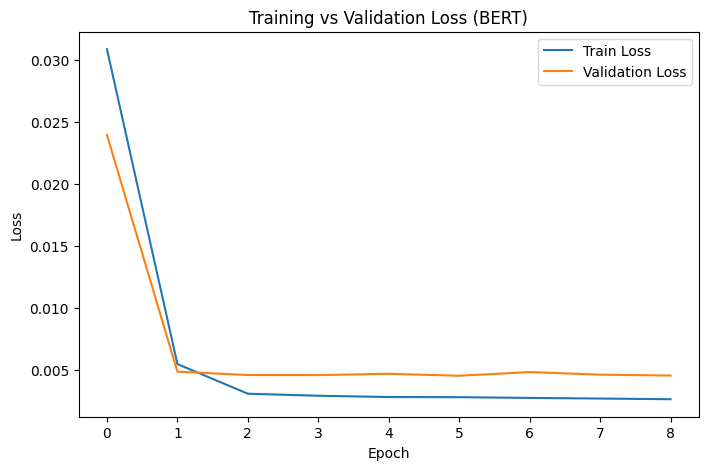

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (BERT)")
plt.legend()

plt.show()

In [29]:
model.load_state_dict(torch.load("bertchunking_task2_model.pt", map_location=DEVICE))
model.eval()

BertChunkingMultiHead(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elem

In [30]:
all_criteria = []
all_overall = []
all_true = []

with torch.no_grad():

    for ids, masks, crit, overall in test_loader:

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)

        crit_pred, overall_pred = model(ids, masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        all_criteria.append(crit_pred.cpu().numpy())
        all_overall.append(overall_pred.cpu().numpy())
        all_true.append(overall.cpu().numpy())

all_criteria = np.vstack(all_criteria) * 9
overall_pred = np.concatenate(all_overall) * 9
overall_true = np.concatenate(all_true) * 9

In [31]:
vectorized_round = np.vectorize(round_band, otypes=[float])

In [32]:
print(overall_pred[:20])
print(vectorized_round(overall_pred)[:20])

[7.7363667 7.1178303 6.162293  6.130654  6.765432  4.278848  8.292916
 6.727796  7.71432   3.9567287 3.1817882 3.998561  3.9631627 4.2325096
 7.649041  4.2559695 7.0488033 7.0518923 8.294045  6.157753 ]
[7.5 7.  6.  6.  7.  4.5 8.5 6.5 7.5 4.  3.  4.  4.  4.  7.5 4.5 7.  7.
 8.5 6. ]


In [33]:
mae = mean_absolute_error(overall_true, overall_pred)
rmse = np.sqrt(mean_squared_error(overall_true, overall_pred))
pearson = pearsonr(overall_true, overall_pred)[0]

within_half = np.mean(np.abs(overall_pred - overall_true) <= 0.5)

true_band = np.round(overall_true * 2).astype(int)
pred_band = np.round(overall_pred * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.3752328157424927
RMSE: 0.5381730523181978
Pearson: 0.9317032
Within ±0.5: 0.7675438596491229
QWK: 0.9252031190250172


In [34]:
criteria_mean = all_criteria.mean(axis=1)

print("\nCONSISTENCY CHECK")
print("MAE(mean(criteria), overall_true):",
      mean_absolute_error(overall_true, criteria_mean))

print("Pearson:",
      pearsonr(criteria_mean, overall_true)[0])


===== CONSISTENCY CHECK =====
MAE(mean(criteria), overall_true): 0.36181703209877014
Pearson: 0.9322914


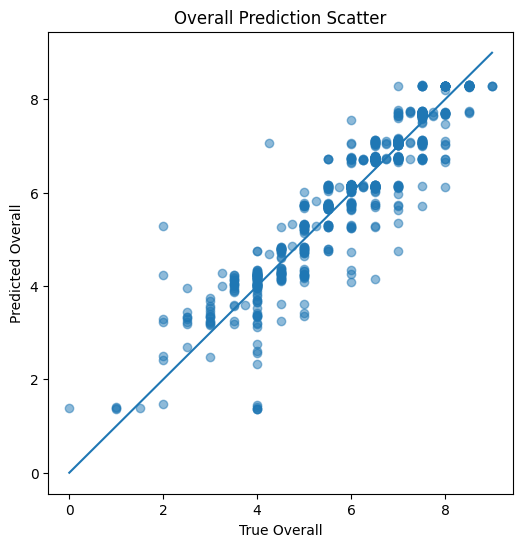

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(overall_true, overall_pred, alpha=0.5)

# đường y = x (perfect prediction)
plt.plot([0, 9], [0, 9])

plt.xlabel("True Overall")
plt.ylabel("Predicted Overall")
plt.title("Overall Prediction Scatter")

plt.show()

In [36]:

test_df = df_full.iloc[test_idx].copy().reset_index(drop=True)

overall_pred_rounded = vectorized_round(overall_pred)
criteria_rounded = vectorized_round(all_criteria)

test_df["overall_pred_raw"] = overall_pred
test_df["overall_pred"] = overall_pred_rounded

test_df["Task_Response_pred"] = all_criteria[:, 0]
test_df["Coherence_Cohesion_pred"] = all_criteria[:, 1]
test_df["Lexical_Resource_pred"] = all_criteria[:, 2]
test_df["Range_Accuracy_pred"] = all_criteria[:, 3]

test_df["Task_Response_pred_round"] = criteria_rounded[:, 0]
test_df["Coherence_Cohesion_pred_round"] = criteria_rounded[:, 1]
test_df["Lexical_Resource_pred_round"] = criteria_rounded[:, 2]
test_df["Range_Accuracy_pred_round"] = criteria_rounded[:, 3]

test_df["error_raw"] = test_df["overall_pred_raw"] - test_df["Overall"]
test_df["error_round"] = test_df["overall_pred"] - test_df["Overall"]

test_df["criteria_mean"] = all_criteria.mean(axis=1)
test_df["criteria_std"] = np.std(all_criteria, axis=1)

test_df.head(10)

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length,...,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Response_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,error_raw,error_round,criteria_std
0,The range of technology available to people is...,The increasing range of technology available t...,8.0,8.0,7.0,7.0,7.0,7.5,### Task Achievement:\n- The candidate has add...,263,...,7.902376,7.381821,7.337668,8.0,8.0,7.5,7.5,0.736367,0.5,0.263171
1,Some people believe that what children watch o...,Televisions can certainly bring a change in a ...,7.0,7.0,6.5,6.5,7.0,7.0,## Task Achievement:\n- The candidate has addr...,298,...,7.181547,6.932833,6.881038,7.0,7.0,7.0,7.0,0.117830,0.0,0.127372
2,Some people think that public health within a ...,Staying healthy is strongly linked to eating n...,6.0,6.0,6.0,6.0,6.0,6.0,**Task Achievement:**\n\nThe candidate has ade...,312,...,6.118193,5.976169,5.972150,6.0,6.0,6.0,6.0,0.162293,0.0,0.083441
3,People nowadays tend to have children at older...,"These days, having a child is one of the most ...",6.5,6.0,6.0,6.0,6.5,6.0,**Task Achievement:** (3.5)\n\nThe essay adequ...,250,...,6.059752,5.962658,5.953610,6.0,6.0,6.0,6.0,-0.369346,-0.5,0.069851
4,Some people say that what children watch influ...,People have different views about whether it i...,6.5,6.5,6.5,6.5,6.5,6.5,## Task Achievement:\n- The candidate has adeq...,321,...,6.700416,6.475226,6.427241,7.0,6.5,6.5,6.5,0.265432,0.5,0.143001
5,Some people think news has no connection to pe...,Some think that to read journalism in the pape...,4.0,4.0,4.0,4.0,4.0,4.0,**Task Achievement:**\n- The candidate has add...,323,...,4.102737,3.980564,4.005140,4.0,4.0,4.0,4.0,0.278848,0.5,0.071907
6,The education of young people is highly priori...,Equitable access to education can change lives...,8.0,8.0,8.0,8.0,8.0,8.0,## Task Achievement:\n- The candidate has addr...,346,...,8.361565,8.097429,8.106866,8.5,8.5,8.0,8.0,0.292916,0.5,0.133533
7,Some people believe that watching TV is bad fo...,People fall into two camps as to whether watc...,6.0,7.0,6.5,6.0,6.0,6.5,## Task Achievement:\nThe candidate has adequa...,247,...,6.672946,6.433692,6.396087,6.5,6.5,6.5,6.5,0.727796,0.5,0.144045
8,Some people think that robots are important fo...,"In the industrial revolution 5.0, the adoption...",7.5,7.5,7.5,7.5,8.0,7.5,## Task Achievement:\nThe candidate has addres...,316,...,7.871859,7.353258,7.333576,8.0,8.0,7.5,7.5,-0.285680,-0.5,0.255226
9,Nowadays many job seekers are finding jobs tha...,"To begin with, a lot of people believe they ca...",3.5,3.5,3.0,3.0,3.5,3.5,## Task Achievement:\n- The candidate has addr...,240,...,3.535658,3.366528,3.312532,4.0,3.5,3.5,3.5,0.456729,0.5,0.201046


In [37]:
df_missing["input_text"] = (
    "Overall Score: " + df_missing["Overall_Clean"].astype(str) +
    " | Word count: " + df_missing["length"].astype(str) +
    " | Question: " + df_missing["Question"].astype(str) +
    " [SEP] Essay: " + df_missing["Essay"].astype(str)
)

encoded_missing = tokenizer(
    df_missing["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

missing_ids = encoded_missing["input_ids"]
missing_masks = encoded_missing["attention_mask"]

model.eval()

all_criteria_missing = []
all_overall_missing = []

with torch.no_grad():

    for i in range(0, len(missing_ids), BATCH_SIZE):

        batch_ids = missing_ids[i:i+BATCH_SIZE].to(DEVICE)
        batch_masks = missing_masks[i:i+BATCH_SIZE].to(DEVICE)

        crit_pred, overall_pred = model(batch_ids, batch_masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        overall_batch = df_missing["Overall_Clean"].values[i:i+BATCH_SIZE] / 9.0
        overall_batch = torch.tensor(overall_batch, dtype=torch.float32).to(DEVICE)

        scale = overall_batch / (crit_pred.mean(dim=1) + 1e-6)
        crit_pred = crit_pred * scale.unsqueeze(1)

        all_criteria_missing.append(crit_pred.cpu().numpy())
        all_overall_missing.append(overall_pred.cpu().numpy())

all_criteria_missing = np.vstack(all_criteria_missing) * 9
overall_missing_pred = np.concatenate(all_overall_missing) * 9

In [38]:
criteria_missing_rounded = vectorized_round(all_criteria_missing)
overall_missing_rounded = vectorized_round(overall_missing_pred)

missing_df = df_missing.copy().reset_index(drop=True)

missing_df["overall_pred_raw"] = overall_missing_pred
missing_df["overall_pred"] = overall_missing_rounded

missing_df["Task_Achievement_pred"] = all_criteria_missing[:, 0]
missing_df["Coherence_Cohesion_pred"] = all_criteria_missing[:, 1]
missing_df["Lexical_Resource_pred"] = all_criteria_missing[:, 2]
missing_df["Range_Accuracy_pred"] = all_criteria_missing[:, 3]

missing_df["Task_Achievement_pred_round"] = criteria_missing_rounded[:, 0]
missing_df["Coherence_Cohesion_pred_round"] = criteria_missing_rounded[:, 1]
missing_df["Lexical_Resource_pred_round"] = criteria_missing_rounded[:, 2]
missing_df["Range_Accuracy_pred_round"] = criteria_missing_rounded[:, 3]

missing_df["criteria_mean"] = all_criteria_missing.mean(axis=1)
missing_df["criteria_std"] = np.std(all_criteria_missing, axis=1)

missing_df.head(10)

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length,...,Task_Achievement_pred,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Achievement_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,criteria_mean,criteria_std
0,Many people assume that the goal of every coun...,More materials and goods are produced by a cou...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,435,...,6.624791,6.679353,6.390960,6.304861,6.5,6.5,6.5,6.5,6.499991,0.156292
1,Some people believe that giving longer prison ...,There is an opinion which is that the longer p...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,295,...,6.084181,6.069075,5.914103,5.932603,6.0,6.0,6.0,6.0,5.999990,0.077101
2,Some people believe that preserving natural en...,Some people believe that preserving natural en...,NaN,NaN,NaN,NaN,8.0,8.0,NaN,371,...,8.153516,8.126805,7.860614,7.859028,8.0,8.0,8.0,8.0,7.999991,0.140489
3,Some people believe that homework should not b...,The benefits of giving or not giving homework ...,NaN,NaN,NaN,NaN,9.0,9.0,NaN,309,...,9.195529,9.169636,8.831721,8.803074,9.0,9.0,9.0,9.0,8.999990,0.183102
4,Some people believe that governments should pa...,This essay agrees on the need of that governme...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,311,...,5.729354,5.512503,5.459004,5.299102,5.5,5.5,5.5,5.5,5.499990,0.153948
5,Some people believe that governments should pa...,Regarding the suggestions that governments sho...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,267,...,6.063153,6.085940,5.928434,5.922436,6.0,6.0,6.0,6.0,5.999990,0.075020
6,Some people believe that governments should pa...,Nowadays many people argue that univerties gra...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,265,...,5.720063,5.501595,5.441590,5.336714,5.5,5.5,5.5,5.5,5.499991,0.140093
7,Some people believe that governments should pa...,It is believed that governments ought to pay f...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,258,...,6.638909,6.646419,6.404527,6.310108,6.5,6.5,6.5,6.5,6.499990,0.146551
8,Some people believe that governments should pa...,"In recent years, in some countries, including ...",NaN,NaN,NaN,NaN,5.5,5.5,NaN,339,...,5.738499,5.447303,5.495914,5.318248,5.5,5.5,5.5,5.5,5.499991,0.152241
9,Some people believe that governments should pa...,Going to university is an important step in li...,NaN,NaN,NaN,NaN,7.5,7.5,NaN,409,...,7.722142,7.793728,7.285198,7.198894,7.5,8.0,7.5,7.0,7.499990,0.260973
